In [1]:
# 1. Pobranie danych

import yfinance as yf
import pandas as pd
from pathlib import Path

# =========================
# Parametry
# =========================
TICKER = "^GSPC"
START_DATE = "1900-01-01"
END_DATE = None
INTERVAL = "1d"

DATA_DIR = Path("data/market")
DATA_DIR.mkdir(parents=True, exist_ok=True)

FILE_PATH = DATA_DIR / f"{TICKER.replace('^','')}_{INTERVAL}.parquet"


def load_or_download_data(
    ticker: str,
    start: str,
    end: str | None,
    interval: str,
    file_path: Path
) -> pd.DataFrame:
    """
    Ładuje dane z dysku jeśli istnieją,
    w przeciwnym razie pobiera je z yfinance i zapisuje.
    """

    if file_path.exists():
        print(f"[INFO] Wczytywanie danych z cache: {file_path}")
        try:
            df = pd.read_parquet(file_path)
            return df
        except Exception as e:
            raise RuntimeError(
                f"Błąd podczas wczytywania danych z {file_path}"
            ) from e

    print("[INFO] Brak danych w cache — pobieranie z yfinance...")
    try:
        df = yf.download(
            tickers=ticker,
            start=start,
            end=end,
            interval=interval,
            auto_adjust=False,
            progress=False
        )
    except Exception as e:
        raise RuntimeError("Błąd podczas pobierania danych z yfinance") from e

    if df.empty:
        raise ValueError("Pobrane dane są puste — sprawdź ticker lub zakres dat")

    # Spłaszczenie MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    # Standaryzacja nazw kolumn
    df = df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume"
    })

    df = df.dropna()

    try:
        df.to_parquet(file_path)
        print(f"[INFO] Dane zapisane do: {file_path}")
    except Exception as e:
        raise RuntimeError(
            f"Nie udało się zapisać danych do {file_path}"
        ) from e

    return df


# =========================
# Użycie
# =========================
df = load_or_download_data(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    file_path=FILE_PATH
)

print(df.head())
print(df.tail())
print(df.info())


[INFO] Wczytywanie danych z cache: data/market/GSPC_1d.parquet
            adj_close      close       high        low       open  volume
Date                                                                     
1927-12-30  17.660000  17.660000  17.660000  17.660000  17.660000       0
1928-01-03  17.760000  17.760000  17.760000  17.760000  17.760000       0
1928-01-04  17.719999  17.719999  17.719999  17.719999  17.719999       0
1928-01-05  17.549999  17.549999  17.549999  17.549999  17.549999       0
1928-01-06  17.660000  17.660000  17.660000  17.660000  17.660000       0
              adj_close        close         high          low         open  \
Date                                                                          
2026-01-28  6978.029785  6978.029785  7002.279785  6963.459961  7002.000000   
2026-01-29  6969.009766  6969.009766  6992.839844  6870.799805  6977.740234   
2026-01-30  6939.029785  6939.029785  6964.089844  6893.479980  6947.270020   
2026-02-02  6976.439941 

In [2]:
# 2. Walidacja danych
import pandas as pd
import numpy as np
from datetime import timedelta
from pathlib import Path

# =============================================================================
# Parametry walidacji (można wyciągnąć do configu)
# =============================================================================
EXPECTED_FREQ = "1D"               # oczekujemy dziennych danych
MAX_GAP_DAYS = 10                  # maksymalna dopuszczalna przerwa w handlu
MIN_ROWS = 500                     # minimalna sensowna liczba obserwacji
TOLERATED_MISSING_PCT = 0.005      # dopuszczalny % brakujących wartości

# Plik do którego zapiszemy brakujące dni sesyjne (jeśli są)
MISSING_TRADING_DAYS_CSV = "critical_missing_trading_days.csv"

# =============================================================================
# Funkcja walidacyjna – z zapisem brakujących dni do CSV
# =============================================================================
def validate_market_data(df: pd.DataFrame) -> dict:
    """
    Przeprowadza podstawową walidację danych OHLCV + zwraca raport.
    Zwraca słownik z wynikami + listę ostrzeżeń/błędów krytycznych.
    """
    report = {
        "is_valid": True,
        "critical_issues": [],
        "warnings": [],
        "stats": {}
    }

    # 1. Podstawowe sprawdzenia kształtu i typów
    if df.empty:
        report["critical_issues"].append("DataFrame jest pusty")
        report["is_valid"] = False
        return report

    required_cols = {"open", "high", "low", "close", "volume"}
    missing_cols = required_cols - set(df.columns.str.lower())
    if missing_cols:
        report["critical_issues"].append(f"Brakujące kolumny: {missing_cols}")
        report["is_valid"] = False

    # 2. Indeks musi być DatetimeIndex i posortowany monotonicznie rosnąco
    if not isinstance(df.index, pd.DatetimeIndex):
        report["critical_issues"].append("Indeks nie jest DatetimeIndex")
        report["is_valid"] = False
    else:
        if not df.index.is_monotonic_increasing:
            report["critical_issues"].append("Indeks nie jest monotonicznie rosnący")
            report["is_valid"] = False
        if df.index.has_duplicates:
            report["critical_issues"].append(f"Znaleziono {df.index.duplicated().sum()} duplikatów indeksu")
            report["is_valid"] = False

    # 3. Sprawdzenie ciągłości dat – z wykorzystaniem NYSE kalendarza
    missing_trading_days_df = None

    if report["is_valid"] and isinstance(df.index, pd.DatetimeIndex):
        try:
            import pandas_market_calendars as mcal

            # Pobieramy kalendarz NYSE
            nyse = mcal.get_calendar('NYSE')

            expected_trading_days = nyse.valid_days(
                start_date=df.index.min().date(),
                end_date=df.index.max().date()
            )

            actual_dates = df.index.normalize().date
            expected_set = set(expected_trading_days.date)
            actual_set = set(actual_dates)

            extra_days   = actual_set  - expected_set
            missing_trading_days = expected_set - actual_set

            report["stats"]["n_expected_trading_days"] = len(expected_set)
            report["stats"]["n_actual_days"]           = len(actual_set)
            report["stats"]["n_missing_trading_days"]  = len(missing_trading_days)
            report["stats"]["n_extra_days"]            = len(extra_days)

            # ────────────────────────────────────────────────────────────────
            # Zapis brakujących dni sesyjnych do CSV – jeśli są krytyczne
            # ────────────────────────────────────────────────────────────────
            if missing_trading_days:
                missing_dates = sorted(pd.to_datetime(list(missing_trading_days)))

                missing_trading_days_df = pd.DataFrame({
                    "missing_trading_day": missing_dates,
                    "weekday": [d.day_name() for d in missing_dates],
                    "isoweek": [d.isocalendar().week for d in missing_dates],
                    "year":    [d.year for d in missing_dates],
                    "month":   [d.month for d in missing_dates],
                    "day":     [d.day for d in missing_dates],
                })

                # Dodajemy informację czy dzień jest w naszych danych (dla porównania)
                missing_trading_days_df["in_data"] = missing_trading_days_df["missing_trading_day"].dt.date.isin(actual_set)

                # Zapisujemy do pliku
                csv_path = Path(MISSING_TRADING_DAYS_CSV)
                missing_trading_days_df.to_csv(csv_path, index=False)
                print(f"\n→ Zapisano brakujące dni sesyjne NYSE do: {csv_path.resolve()}\n")

                # Komunikat w raporcie
                missing_list = sorted(missing_trading_days)[:15]
                missing_str = ", ".join(str(d) for d in missing_list)
                if len(missing_trading_days) > 15:
                    missing_str += f" ... (+{len(missing_trading_days)-15} więcej)"

                if len(missing_trading_days) > 5:
                    report["critical_issues"].append(
                        f"Brakuje {len(missing_trading_days)} dni sesyjnych NYSE "
                        f"(przykłady: {missing_str}) → szczegóły w {MISSING_TRADING_DAYS_CSV}"
                    )
                    report["is_valid"] = False
                else:
                    report["warnings"].append(
                        f"Brakuje {len(missing_trading_days)} dni sesyjnych "
                        f"(przykłady: {missing_str}) → szczegóły w {MISSING_TRADING_DAYS_CSV}"
                    )

            # Największa luka w dniach sesyjnych
            if missing_trading_days:
                missing_dates = sorted(pd.to_datetime(list(missing_trading_days)))
                gaps = pd.Series(missing_dates).diff().dt.days[1:]
                if not gaps.empty:
                    report["stats"]["max_gap_trading_days"] = int(gaps.max()) if not gaps.empty else 1
                    if gaps.max() > 3:
                        report["critical_issues"].append(
                            f"Maksymalna luka w dniach sesyjnych: {gaps.max()} dni"
                        )
                        report["is_valid"] = False

            report["stats"]["calendar_used"] = "NYSE (pandas_market_calendars)"

        except ImportError:
            report["warnings"].append(
                "pandas_market_calendars nie jest zainstalowany → pominięto dokładną walidację kalendarza"
            )
            # fallback ...
            date_diff = df.index.to_series().diff().dt.days
            gaps = date_diff[date_diff > 1].dropna()
            report["stats"]["max_gap_days"] = int(gaps.max()) if not gaps.empty else 1
            report["stats"]["n_gaps_larger_than_1"] = len(gaps)

            if gaps.max() > MAX_GAP_DAYS:
                report["critical_issues"].append(
                    f"Znaleziono lukę > {MAX_GAP_DAYS} dni (max = {gaps.max()}) – bez kalendarza NYSE"
                )
                report["is_valid"] = False

        except Exception as e:
            report["warnings"].append(f"Błąd podczas walidacji kalendarza NYSE: {str(e)}")

    # 4. Sprawdzenie logiki OHLC
    invalid_candles = (
        (df["high"] < df["low"]) |
        (df["close"] > df["high"]) |
        (df["close"] < df["low"]) |
        (df["open"] > df["high"]) |
        (df["open"] < df["low"])
    )
    n_invalid = invalid_candles.sum()
    if n_invalid > 0:
        report["critical_issues"].append(f"Znaleziono {n_invalid} logicznie niemożliwych świec (OHLC)")
        report["is_valid"] = False

    # 5. Volume nie powinien być ujemny
    if (df["volume"] < 0).any():
        report["critical_issues"].append("Znaleziono ujemne wartości volume")
        report["is_valid"] = False

    # 6. Brakujące wartości
    missing_pct = df.isna().mean() * 100
    report["stats"]["missing_pct"] = missing_pct.to_dict()
    if missing_pct.max() > TOLERATED_MISSING_PCT * 100:
        cols_with_missing = missing_pct[missing_pct > TOLERATED_MISSING_PCT * 100].index.tolist()
        report["warnings"].append(
            f"Kolumny z >{TOLERATED_MISSING_PCT*100:.2f}% brakujących: {cols_with_missing}"
        )

    # 7. Minimalna liczba rekordów
    report["stats"]["n_rows"] = len(df)
    if len(df) < MIN_ROWS:
        report["warnings"].append(f"Zbyt mało obserwacji: {len(df)} < {MIN_ROWS}")

    # 8. Najnowsza i najstarsza data
    report["stats"]["date_range"] = f"{df.index.min().date()} → {df.index.max().date()}"

    return report


# =============================================================================
# Wykonanie walidacji
# =============================================================================
validation_report = validate_market_data(df)

print("\n" + "="*80)
print("RAPORT WALIDACJI DANYCH")
print("="*80)
print(f"Status ogólny: {'OK' if validation_report['is_valid'] else 'NIE PRZEZ WALIDACJĘ'}")
print()

if validation_report["critical_issues"]:
    print("Błędy krytyczne:")
    for issue in validation_report["critical_issues"]:
        print(f"✗ {issue}")
    print()

if validation_report["warnings"]:
    print("Ostrzeżenia:")
    for warn in validation_report["warnings"]:
        print(f"! {warn}")
    print()

print("Statystyki:")
for k, v in validation_report["stats"].items():
    print(f" {k:22} : {v}")

# ──────────────────────────────────────────────────────────────────────────────
# Automatyczne wyświetlenie brakujących dni (jeśli plik istnieje)
# ──────────────────────────────────────────────────────────────────────────────
csv_path = Path(MISSING_TRADING_DAYS_CSV)
if csv_path.exists():
    print("\n" + "═"*80)
    print(f"Brakujące dni sesyjne NYSE (zapisane do {csv_path.name}):")
    print("═"*80)
    missing_df = pd.read_csv(csv_path, parse_dates=["missing_trading_day"])
    display(missing_df)           # ładne wyświetlenie w Jupyterze
    print(f"Liczba brakujących dni: {len(missing_df)}")
    print("═"*80 + "\n")

# Jeśli walidacja nie przeszła – przerywamy
if not validation_report["is_valid"]:
    raise RuntimeError("Walidacja danych nie przeszła – sprawdź krytyczne błędy powyżej.")


→ Zapisano brakujące dni sesyjne NYSE do: /Users/p.babel/Documents/handson-ml3/critical_missing_trading_days.csv


RAPORT WALIDACJI DANYCH
Status ogólny: NIE PRZEZ WALIDACJĘ

Błędy krytyczne:
✗ Brakuje 1085 dni sesyjnych NYSE (przykłady: 1927-12-31, 1928-01-07, 1928-01-14, 1928-01-21, 1928-01-28, 1928-02-04, 1928-02-11, 1928-02-18, 1928-02-25, 1928-03-03, 1928-03-10, 1928-03-17, 1928-03-24, 1928-03-31, 1928-04-14 ... (+1070 więcej)) → szczegóły w critical_missing_trading_days.csv
✗ Maksymalna luka w dniach sesyjnych: 140.0 dni

Statystyki:
 n_expected_trading_days : 25724
 n_actual_days          : 24639
 n_missing_trading_days : 1085
 n_extra_days           : 0
 max_gap_trading_days   : 140
 calendar_used          : NYSE (pandas_market_calendars)
 missing_pct            : {'adj_close': 0.0, 'close': 0.0, 'high': 0.0, 'low': 0.0, 'open': 0.0, 'volume': 0.0}
 n_rows                 : 24639
 date_range             : 1927-12-30 → 2026-02-03

═══════════════════════════════════════════════

,missing_trading_day,weekday,isoweek,year,month,day,in_data
0,1927-12-31,Saturday,52,1927,12,31,False
1,1928-01-07,Saturday,1,1928,1,7,False
2,1928-01-14,Saturday,2,1928,1,14,False
3,1928-01-21,Saturday,3,1928,1,21,False
4,1928-01-28,Saturday,4,1928,1,28,False
...,...,...,...,...,...,...,...
1080,1952-04-26,Saturday,17,1952,4,26,False
1081,1952-05-03,Saturday,18,1952,5,3,False
1082,1952-05-10,Saturday,19,1952,5,10,False
1083,1952-05-17,Saturday,20,1952,5,17,False


Liczba brakujących dni: 1085
════════════════════════════════════════════════════════════════════════════════



RuntimeError: Walidacja danych nie przeszła – sprawdź krytyczne błędy powyżej.


=== Podstawowe informacje ===
1927-12-30 – 2026-02-03
Liczba rekordów: 24,639
Średni dzienny zwrot: 0.0314%
Średni dzienny |log return|: 0.7625%

Statystyki kluczowych kolumn:
             open        high         low       close        volume  \
count  24639.0000  24639.0000  24639.0000  24639.0000  2.463900e+04   
mean     720.2455    724.3791    715.8404    720.3911  9.657537e+08   
std     1229.4900   1235.9507   1222.4902   1229.6888  1.680595e+09   
min        4.4000      4.4000      4.4000      4.4000  0.000000e+00   
1%         7.7038      7.7038      7.7038      7.7038  0.000000e+00   
5%        10.0700     10.0700     10.0700     10.0700  0.000000e+00   
25%       24.9400     24.9400     24.9400     24.9400  1.600000e+06   
50%      103.5100    104.3500    102.6500    103.5100  2.203000e+07   
75%     1090.2050   1097.2450   1080.4600   1090.0600  1.168050e+09   
95%     3786.2640   3819.1870   3749.4670   3790.4349  4.565431e+09   
99%     5894.5482   5926.5373   5854.8264 

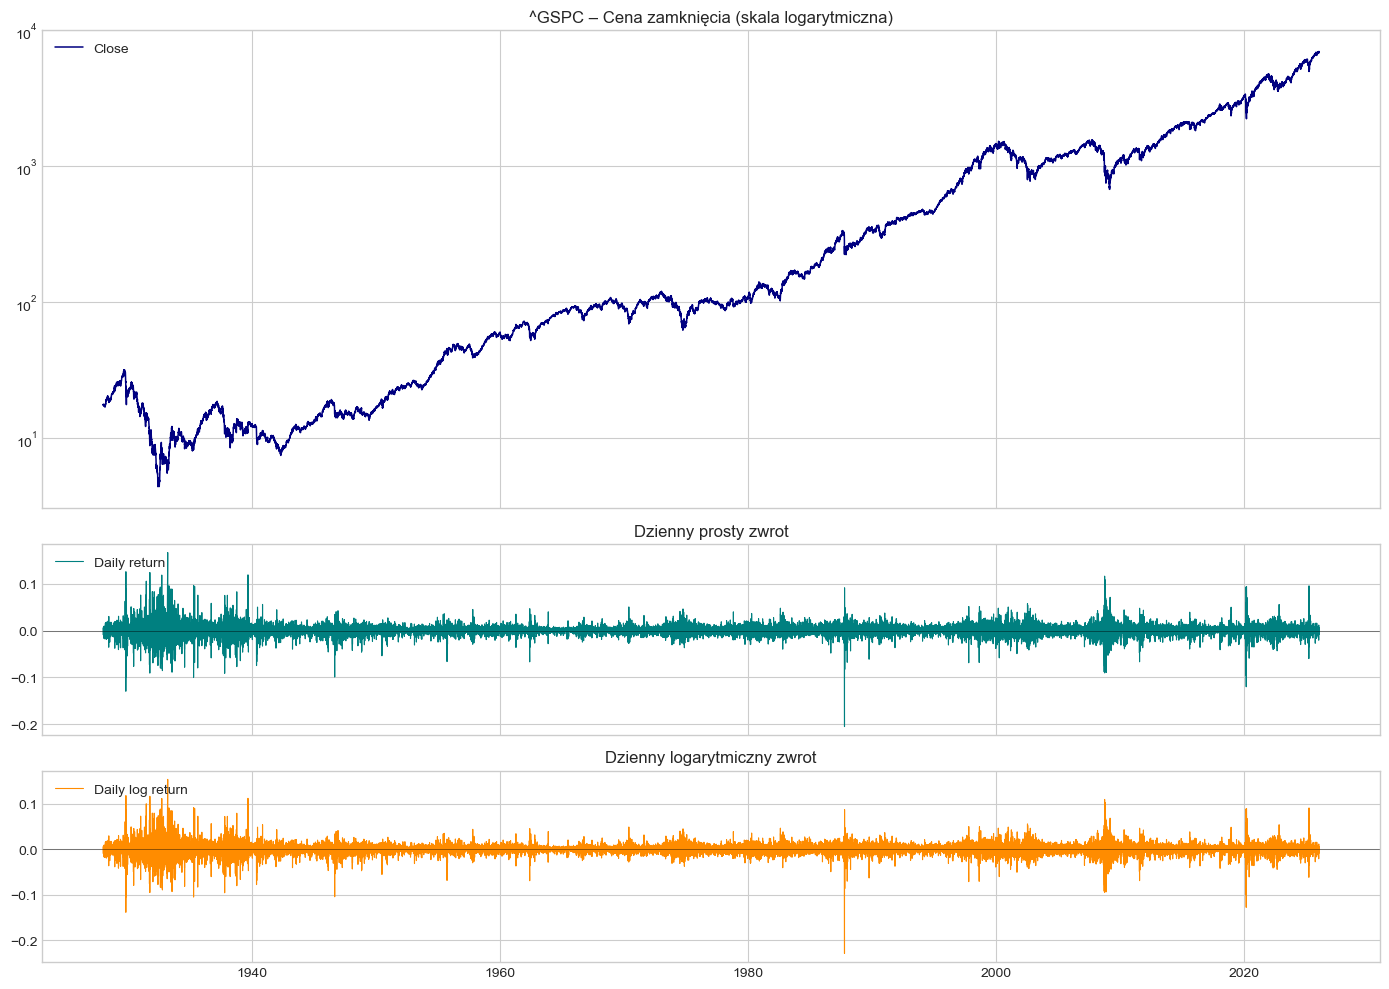

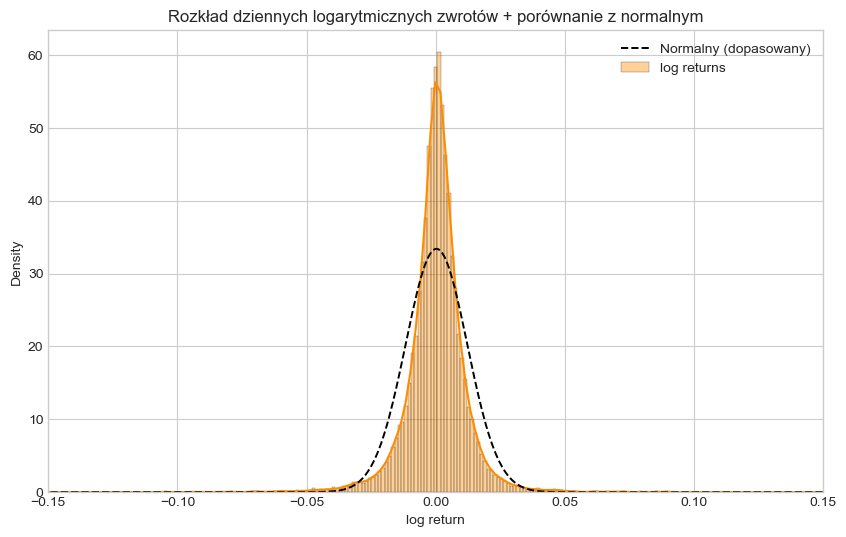

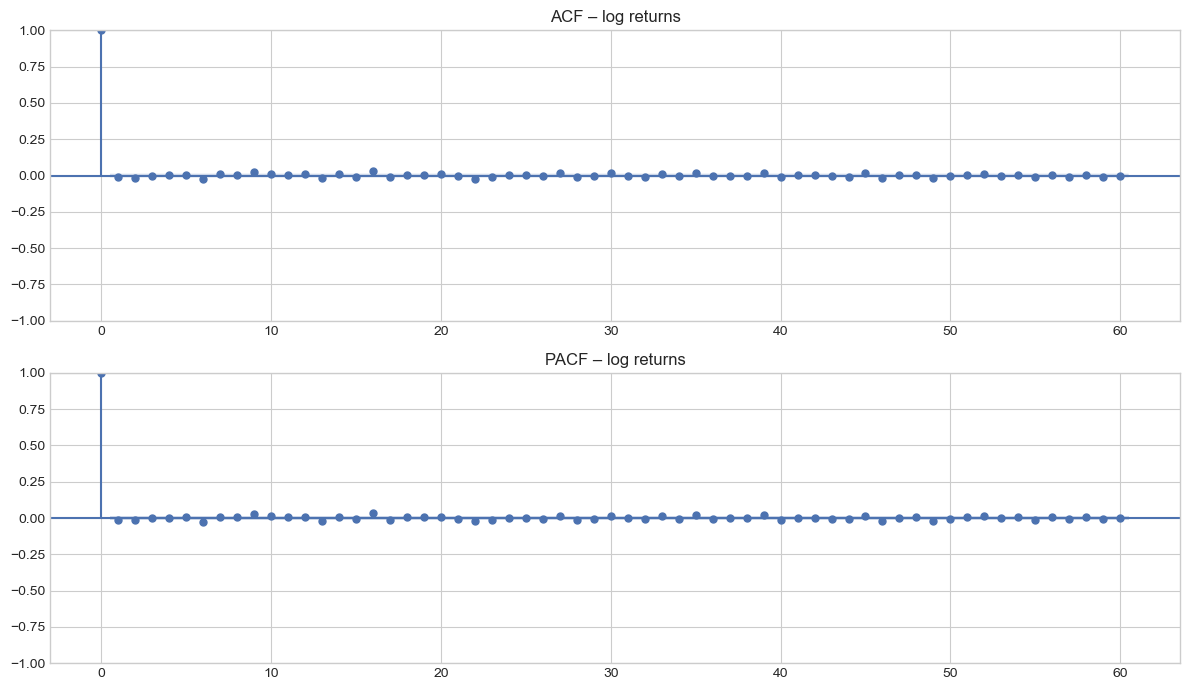

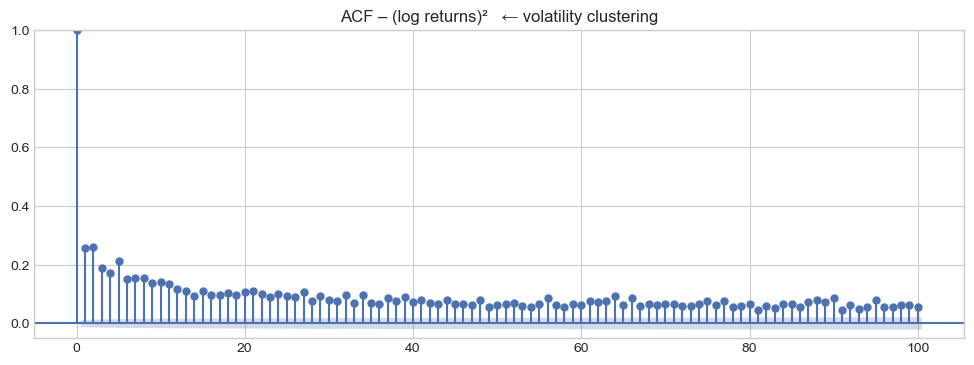


=== 15 największych dziennych spadków ===
Date
1987-10-19   -20.47
1929-10-28   -12.94
2020-03-16   -11.98
1929-10-29   -10.16
1935-04-16    -9.97
1929-11-06    -9.92
1946-09-03    -9.91
2020-03-12    -9.51
1937-10-18    -9.12
1931-10-05    -9.07
2008-10-15    -9.03
2008-12-01    -8.93
1933-07-20    -8.88
2008-09-29    -8.81
1933-07-21    -8.70
Name: return, dtype: float64

=== 15 największych dziennych wzrostów ===
Date
1933-03-15    16.61
1929-10-30    12.53
1931-10-06    12.36
1939-09-05    11.86
1932-09-21    11.81
2008-10-13    11.58
2008-10-28    10.79
1931-06-22    10.51
1935-04-17     9.61
1933-04-20     9.52
2025-04-09     9.52
1935-05-17     9.40
2020-03-24     9.38
2020-03-13     9.29
1932-08-08     9.26
Name: return, dtype: float64
[INFO] adj_close == close w całym zbiorze → pominięto w heatmapie


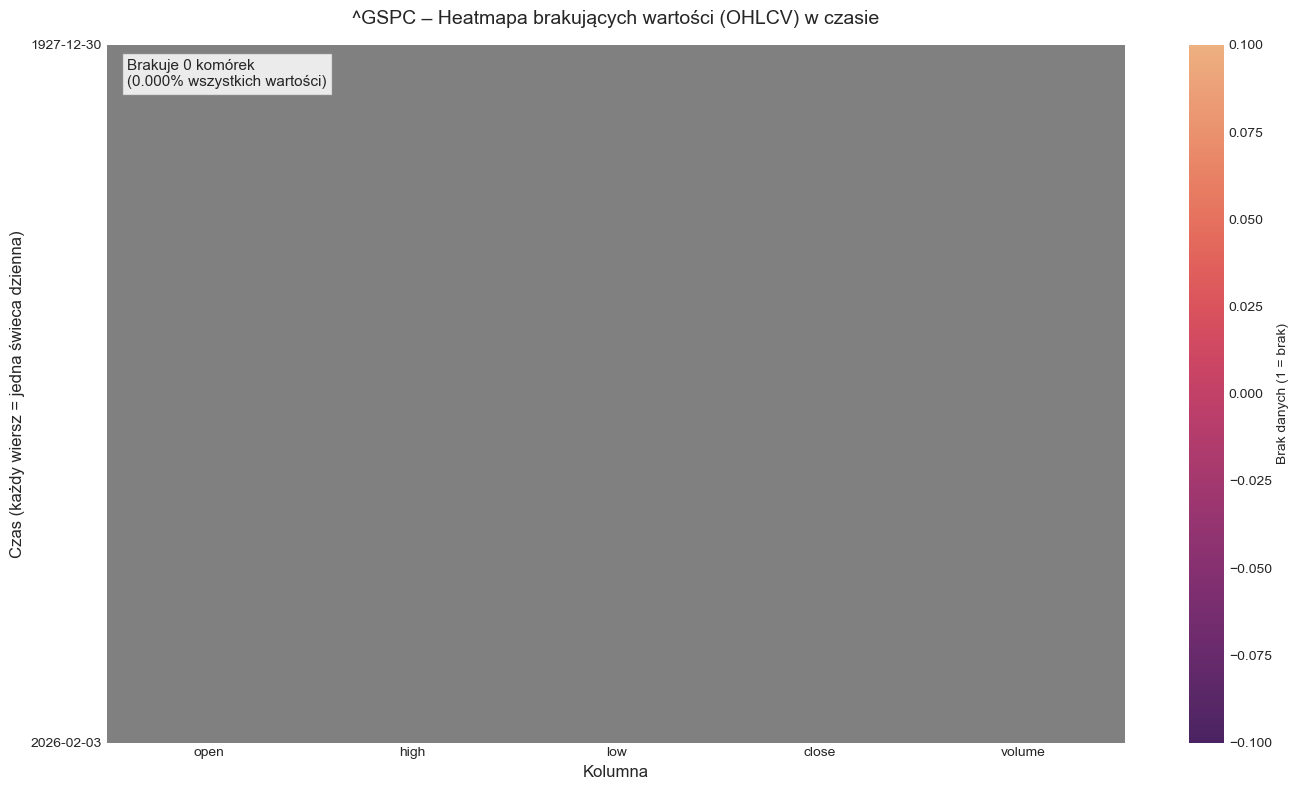


Liczba brakujących wartości w każdej kolumnie:
        Braki (szt.)  % brakujących
open               0            0.0
high               0            0.0
low                0            0.0
close              0            0.0
volume             0            0.0

BRAK BRAKÓW – dane są kompletne w całym zakresie.


In [3]:
# 3. EDA – S&P 500 daily data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
%matplotlib inline
# %config InlineBackend.figure_format = 'retina'   # jeśli używasz Jupyter

# =============================================================================
# Przygotowanie pomocniczych serii (już na etapie EDA – często robimy to tutaj)
# =============================================================================
df["return"]      = df["close"].pct_change()
df["log_return"]  = np.log(df["close"] / df["close"].shift(1))
df["range"]       = (df["high"] - df["low"]) / df["close"].shift(1)   # daily range %
df["body"]        = (df["close"] - df["open"]) / df["open"]
df["upper_wick"]  = (df["high"] - df[["open","close"]].max(axis=1)) / df["close"]
df["lower_wick"]  = (df[["open","close"]].min(axis=1) - df["low"]) / df["close"]

# =============================================================================
# 3.1 Podstawowe spojrzenie
# =============================================================================
print("\n=== Podstawowe informacje ===")
print(df.index.min().date(), "–", df.index.max().date())
print(f"Liczba rekordów: {len(df):,d}")
print(f"Średni dzienny zwrot: {df['return'].mean():.4%}")
print(f"Średni dzienny |log return|: {df['log_return'].abs().mean():.4%}")
print("\nStatystyki kluczowych kolumn:")
print(df[["open","high","low","close","volume","return","log_return"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).round(4))

# =============================================================================
# 3.2 Wizualizacja ceny i zwrotów
# =============================================================================
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1.2, 1.2]})

# Cena (log scale!)
axs[0].plot(df["close"], color="navy", lw=1.1, label="Close")
axs[0].set_yscale("log")
axs[0].set_title(f"{TICKER} – Cena zamknięcia (skala logarytmiczna)")
axs[0].legend(loc="upper left")

# Zwroty dzienne
axs[1].plot(df["return"], color="teal", lw=0.8, label="Daily return")
axs[1].axhline(0, color="black", lw=0.6, alpha=0.5)
axs[1].set_title("Dzienny prosty zwrot")
axs[1].legend(loc="upper left")

# Logarytmiczne zwroty (częściej używane w modelach)
axs[2].plot(df["log_return"], color="darkorange", lw=0.8, label="Daily log return")
axs[2].axhline(0, color="black", lw=0.6, alpha=0.5)
axs[2].set_title("Dzienny logarytmiczny zwrot")
axs[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

# =============================================================================
# 3.3 Rozkłady – porównanie normalnego + fat tails
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df["log_return"].dropna(), bins=300, kde=True, stat="density",
             color="darkorange", alpha=0.4, label="log returns")

# Dla porównania – normalny rozkład o takiej samej średniej i wariancji
x = np.linspace(df["log_return"].min(), df["log_return"].max(), 500)
normal_pdf = (1 / (df["log_return"].std() * np.sqrt(2*np.pi))) * \
             np.exp( - (x - df["log_return"].mean())**2 / (2 * df["log_return"].std()**2) )
ax.plot(x, normal_pdf, "k--", lw=1.4, label="Normalny (dopasowany)")

ax.set_title("Rozkład dziennych logarytmicznych zwrotów + porównanie z normalnym")
ax.set_xlabel("log return")
ax.set_xlim([-0.15, 0.15])   # zoom na centralną część – ogony widać dalej
ax.legend()
plt.show()

# =============================================================================
# 3.4 Autokorelacja zwrotów i kwadratów zwrotów (klucz do volatility clustering)
# =============================================================================
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(df["log_return"].dropna(), lags=60, ax=axs[0], title="ACF – log returns")
plot_pacf(df["log_return"].dropna(), lags=60, ax=axs[1], title="PACF – log returns", method="ywm")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df["log_return"].dropna()**2, lags=100, ax=ax,
         title="ACF – (log returns)²   ← volatility clustering")
ax.set_ylim(bottom=-0.05)
plt.show()

# =============================================================================
# 3.5 Największe ruchy w historii (pomaga zrozumieć ekstremalne przypadki)
# =============================================================================
print("\n=== 15 największych dziennych spadków ===")
print(df["return"].nsmallest(15).round(4) * 100)

print("\n=== 15 największych dziennych wzrostów ===")
print(df["return"].nlargest(15).round(4) * 100)

# 3.6 Heatmapa braków w czasie – dla kolumn OHLC(V)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------------------------------------------
# Przygotowanie macierzy brakujących wartości (True = brak)
# --------------------------------------------------------------------
missing_matrix = df[["open", "high", "low", "close", "adj_close", "volume"]].isna()

# Jeśli adj_close jest identyczne z close → często yfinance to robi → możemy je pominąć w wizualizacji
if (df["close"] == df["adj_close"]).all():
    missing_matrix = missing_matrix.drop(columns=["adj_close"])
    print("[INFO] adj_close == close w całym zbiorze → pominięto w heatmapie")

# --------------------------------------------------------------------
# Heatmapa – pionowo czas, poziomo kolumny
# --------------------------------------------------------------------
plt.figure(figsize=(14, 8))

# Główna heatmapa
ax = sns.heatmap(
    missing_matrix,
    cmap="flare_r",           # czerwony = brak, jasny = obecne
    cbar_kws={'label': 'Brak danych (1 = brak)'},
    yticklabels=False,        # za dużo wierszy → etykiety y nieczytelne
    xticklabels=True,
    linewidths=0.01,
    linecolor='gray'
)

# Dodatkowe linie pionowe rozdzielające kolumny
ax.vlines(np.arange(0, missing_matrix.shape[1]+1), *ax.get_ylim(), color='gray', lw=0.8)

# Tytuł i podpisy
plt.title(f"{TICKER} – Heatmapa brakujących wartości (OHLCV) w czasie", fontsize=14, pad=15)
plt.xlabel("Kolumna", fontsize=12)
plt.ylabel("Czas (każdy wiersz = jedna świeca dzienna)", fontsize=12)

# Mały trik – pokazujemy zakres dat na osi Y (tylko początek i koniec)
n_rows = len(df)
plt.yticks([0, n_rows-1], [df.index[0].strftime("%Y-%m-%d"), df.index[-1].strftime("%Y-%m-%d")])

# Statystyka w rogu
total_cells = missing_matrix.size
missing_cells = missing_matrix.sum().sum()
missing_pct = missing_cells / total_cells * 100

plt.text(
    0.02, 0.98,
    f"Brakuje {missing_cells:,} komórek\n({missing_pct:.3f}% wszystkich wartości)",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# Dodatkowe szybkie podsumowanie brakujących po kolumnach
# --------------------------------------------------------------------
print("\nLiczba brakujących wartości w każdej kolumnie:")
missing_counts = missing_matrix.sum()
missing_percent = missing_matrix.mean() * 100
summary = pd.DataFrame({
    "Braki (szt.)": missing_counts,
    "% brakujących": missing_percent.round(4)
}).sort_values("Braki (szt.)", ascending=False)

print(summary)

if missing_counts.sum() == 0:
    print("\nBRAK BRAKÓW – dane są kompletne w całym zakresie.")
elif missing_counts["volume"] > 0 and missing_counts[["open","high","low","close"]].sum().sum() == 0:
    print("\nTylko volume ma braki – typowe dla niektórych źródeł danych.")

In [4]:
# 4. Czyszczenie danych i ponowna walidacja

df = df[df.index >= "1953-01-01"].copy()

In [5]:
# =============================================================================
# Wykonanie walidacji ponownie, po usunięciu danych
# =============================================================================
validation_report = validate_market_data(df)

print("\n" + "="*80)
print("RAPORT WALIDACJI DANYCH")
print("="*80)
print(f"Status ogólny: {'OK' if validation_report['is_valid'] else 'NIE PRZEZ WALIDACJĘ'}")
print()

if validation_report["critical_issues"]:
    print("Błędy krytyczne:")
    for issue in validation_report["critical_issues"]:
        print(f"✗ {issue}")
    print()

if validation_report["warnings"]:
    print("Ostrzeżenia:")
    for warn in validation_report["warnings"]:
        print(f"! {warn}")
    print()

print("Statystyki:")
for k, v in validation_report["stats"].items():
    print(f" {k:22} : {v}")

# ──────────────────────────────────────────────────────────────────────────────
# Automatyczne wyświetlenie brakujących dni (jeśli plik istnieje)
# ──────────────────────────────────────────────────────────────────────────────
csv_path = Path(MISSING_TRADING_DAYS_CSV)
if csv_path.exists():
    print("\n" + "═"*80)
    print(f"Brakujące dni sesyjne NYSE (zapisane do {csv_path.name}):")
    print("═"*80)
    missing_df = pd.read_csv(csv_path, parse_dates=["missing_trading_day"])
    display(missing_df)           # ładne wyświetlenie w Jupyterze
    print(f"Liczba brakujących dni: {len(missing_df)}")
    print("═"*80 + "\n")

# Jeśli walidacja nie przeszła – przerywamy
if not validation_report["is_valid"]:
    raise RuntimeError("Walidacja danych nie przeszła – sprawdź krytyczne błędy powyżej.")


RAPORT WALIDACJI DANYCH
Status ogólny: OK

Statystyki:
 n_expected_trading_days : 18395
 n_actual_days          : 18395
 n_missing_trading_days : 0
 n_extra_days           : 0
 calendar_used          : NYSE (pandas_market_calendars)
 missing_pct            : {'adj_close': 0.0, 'close': 0.0, 'high': 0.0, 'low': 0.0, 'open': 0.0, 'volume': 0.0, 'return': 0.0, 'log_return': 0.0, 'range': 0.0, 'body': 0.0, 'upper_wick': 0.0, 'lower_wick': 0.0}
 n_rows                 : 18395
 date_range             : 1953-01-02 → 2026-02-03

════════════════════════════════════════════════════════════════════════════════
Brakujące dni sesyjne NYSE (zapisane do critical_missing_trading_days.csv):
════════════════════════════════════════════════════════════════════════════════


,missing_trading_day,weekday,isoweek,year,month,day,in_data
0,1927-12-31,Saturday,52,1927,12,31,False
1,1928-01-07,Saturday,1,1928,1,7,False
2,1928-01-14,Saturday,2,1928,1,14,False
3,1928-01-21,Saturday,3,1928,1,21,False
4,1928-01-28,Saturday,4,1928,1,28,False
...,...,...,...,...,...,...,...
1080,1952-04-26,Saturday,17,1952,4,26,False
1081,1952-05-03,Saturday,18,1952,5,3,False
1082,1952-05-10,Saturday,19,1952,5,10,False
1083,1952-05-17,Saturday,20,1952,5,17,False


Liczba brakujących dni: 1085
════════════════════════════════════════════════════════════════════════════════



In [7]:
# 5. Feature engineering

import numpy as np
import pandas as pd

EPS = 1e-12

def add_log_returns(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    eps: float = EPS,
    prefix: str = "lr",
) -> pd.DataFrame:
    """Adds log-returns features (movement language)."""
    out = df.copy()
    c = out[close_col].astype(float)
    out[f"{prefix}_1"] = np.log((c + eps) / (c.shift(1) + eps))
    return out


def add_candle_anatomy(
    df: pd.DataFrame,
    *,
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    eps: float = EPS,
    prefix: str = "candle",
) -> pd.DataFrame:
    """Adds candle anatomy features (body, wicks, direction), normalized by candle range."""
    out = df.copy()

    o = out[open_col].astype(float)
    h = out[high_col].astype(float)
    l = out[low_col].astype(float)
    c = out[close_col].astype(float)

    body = (c - o).abs()
    upper_wick = h - np.maximum(o, c)
    lower_wick = np.minimum(o, c) - l
    rng = (h - l).abs()

    denom = rng + eps

    out[f"{prefix}_body_norm_rng"] = body / denom
    out[f"{prefix}_upper_wick_norm_rng"] = upper_wick / denom
    out[f"{prefix}_lower_wick_norm_rng"] = lower_wick / denom
    out[f"{prefix}_direction"] = np.sign(c - o)

    return out


def _true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    """True Range for ATR (no future leakage)."""
    prev_close = close.shift(1)
    tr = pd.concat(
        [
            (high - low).abs(),
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return tr


def add_volatility_features(
    df: pd.DataFrame,
    *,
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    atr_window: int = 14,
    ret_std_window: int = 20,
    atr_ref_window: int = 100,
    logret_col: str = "lr_1",  # oczekuje, że add_log_returns już był wywołany
    eps: float = EPS,
    prefix: str = "vol",
) -> pd.DataFrame:
    """
    Adds volatility features:
      - ATR
      - ATR relative regime (ATR / rolling mean ATR)
      - Rolling std of log-returns
    """
    out = df.copy()

    h = out[high_col].astype(float)
    l = out[low_col].astype(float)
    c = out[close_col].astype(float)

    tr = _true_range(h, l, c)
    atr = tr.rolling(atr_window, min_periods=atr_window).mean()
    out[f"{prefix}_atr_{atr_window}"] = atr

    atr_ref = atr.rolling(atr_ref_window, min_periods=atr_ref_window).mean()
    out[f"{prefix}_atr_rel"] = atr / (atr_ref + eps)

    if logret_col in out.columns:
        out[f"{prefix}_ret_std_{ret_std_window}"] = out[logret_col].rolling(
            ret_std_window, min_periods=ret_std_window
        ).std()
    else:
        # Jeśli nie ma logret_col, nie liczymy rolling std (albo możesz podnieść błąd)
        out[f"{prefix}_ret_std_{ret_std_window}"] = np.nan

    return out


def add_volume_features(
    df: pd.DataFrame,
    *,
    volume_col: str = "volume",
    volume_window: int = 50,
    eps: float = EPS,
    prefix: str = "volm",
) -> pd.DataFrame:
    """Adds volume features (engagement): relative volume + log1p(relative volume)."""
    out = df.copy()
    v = out[volume_col].astype(float)

    v_mean = v.rolling(volume_window, min_periods=volume_window).mean()
    rel_v = v / (v_mean + eps)

    out[f"{prefix}_rel"] = rel_v
    out[f"{prefix}_log1p_rel"] = np.log1p(rel_v.clip(lower=0))

    return out


def add_features_v0_1(
    df: pd.DataFrame,
    *,
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    volume_col: str = "volume",
    atr_window: int = 14,
    ret_std_window: int = 20,
    atr_ref_window: int = 100,
    volume_window: int = 50,
) -> pd.DataFrame:
    """Orchestrates v0.1 feature set with clear separation of responsibilities."""
    required = {open_col, high_col, low_col, close_col, volume_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Brakuje kolumn w df: {missing}")

    out = df.copy()

    # 1) Movement
    out = add_log_returns(out, close_col=close_col, prefix="lr")

    # 2) Candle structure
    out = add_candle_anatomy(
        out,
        open_col=open_col,
        high_col=high_col,
        low_col=low_col,
        close_col=close_col,
        prefix="candle",
    )

    # 3) Volatility regime (uses lr_1 if present)
    out = add_volatility_features(
        out,
        high_col=high_col,
        low_col=low_col,
        close_col=close_col,
        atr_window=atr_window,
        ret_std_window=ret_std_window,
        atr_ref_window=atr_ref_window,
        logret_col="lr_1",
        prefix="vol",
    )

    # 4) Engagement
    out = add_volume_features(
        out,
        volume_col=volume_col,
        volume_window=volume_window,
        prefix="volm",
    )

    return out


In [8]:
df_feat = add_features_v0_1(df)  # df musi mieć: open, high, low, close, volume

In [ ]:
# 6. Ponowna walidacja danych po feature engineering

In [9]:
# 6. Ponowna walidacja danych

import pandas as pd
import numpy as np

# ──────────────────────────────────────────────────────────────────────────────
# Na początek: metody do inspekcji nowych cech
# ──────────────────────────────────────────────────────────────────────────────

# Wyświetlenie pierwszych i ostatnich wierszy z nowymi cechami
print("Pierwsze 5 wierszy z nowymi cechami:")
print(df_feat.head())
print("\nOstatnie 5 wierszy z nowymi cechami:")
print(df_feat.tail())

# Podsumowanie informacji o DataFrame (kolumny, typy, NaN)
print("\nInformacje o DataFrame po feature engineering:")
print(df_feat.info())

# Statystyki opisowe dla nowych cech (min, max, mean, std, etc.)
new_feature_cols = [
    col for col in df_feat.columns
    if col not in ["open", "high", "low", "close", "adj_close", "volume"]
]
print("\nStatystyki opisowe dla nowych cech:")
print(df_feat[new_feature_cols].describe())

# Przykładowe sanity checks wizualne (opcjonalnie: wizualizacja rozkładów)
# import matplotlib.pyplot as plt
# for col in new_feature_cols:
#     plt.figure(figsize=(8, 4))
#     df_feat[col].hist(bins=50)
#     plt.title(f"Rozkład cechy: {col}")
#     plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Ponowna walidacja: sprawdzenie NaN/inf, leakage, sanity checks
# ──────────────────────────────────────────────────────────────────────────────

def validate_features(
    df: pd.DataFrame,
    *,
    feature_cols: list[str] | None = None,
    ohlcv_cols: list[str] = ["open", "high", "low", "close", "volume"],
    eps: float = 1e-12,
    max_nan_pct: float = 0.01,  # max % NaN dopuszczalne
    allow_inf: bool = False,
) -> dict:
    """
    Walidacja po feature engineering:
    - NaN / inf w nowych cechach
    - Sanity checks (np. normalized w [0,1], brak negatywnych gdzie nie powinno)
    - Leakage check: symulacja, czy cechy zależą tylko od przeszłości
    """
    out = df.copy()
    issues = []
    warnings = []
    stats = {}

    if feature_cols is None:
        feature_cols = [c for c in out.columns if c not in ohlcv_cols + ["adj_close"]]

    # 1) NaN check
    nan_counts = out[feature_cols].isna().sum()
    nan_pct = nan_counts / len(out)
    stats["nan_pct_per_feature"] = nan_pct.to_dict()
    high_nan = nan_pct[nan_pct > max_nan_pct]
    if not high_nan.empty:
        issues.append(
            f"Za dużo NaN w cechach: {high_nan.to_dict()} (próg: {max_nan_pct*100}%)"
        )

    # 2) Inf check
    inf_counts = np.isinf(out[feature_cols]).sum()
    if not allow_inf and inf_counts.sum() > 0:
        issues.append(f"Znaleziono inf w cechach: {inf_counts[inf_counts > 0].to_dict()}")

    # 3) Sanity checks specyficzne dla cech
    # - Normalized candle parts: [0,1] i suma ~1
    if all(c in out for c in ["candle_body_norm_rng", "candle_upper_wick_norm_rng", "candle_lower_wick_norm_rng"]):
        candle_parts = out[["candle_body_norm_rng", "candle_upper_wick_norm_rng", "candle_lower_wick_norm_rng"]]
        if (candle_parts < -eps).any().any() or (candle_parts > 1 + eps).any().any():
            issues.append("Normalized candle parts poza [0,1]")
        
        sums = candle_parts.sum(axis=1)
        if not np.allclose(sums, 1.0, atol=eps):
            issues.append(f"Suma normalized candle parts !=1 (max diff: {np.abs(sums - 1).max()})")

    # - Direction: tylko -1,0,1
    if "candle_direction" in out:
        invalid_dir = ~out["candle_direction"].isin([-1, 0, 1])
        if invalid_dir.any():
            issues.append(f"Nieprawidłowe wartości w candle_direction: {out['candle_direction'][invalid_dir].unique()}")

    # - Volatility: ATR >0, rel >0
    if "vol_atr_14" in out:
        if (out["vol_atr_14"] < -eps).any():
            issues.append("Negatywne wartości w ATR")
    if "vol_atr_rel" in out:
        if (out["vol_atr_rel"] < -eps).any():
            issues.append("Negatywne wartości w ATR rel")

    # - Volume rel >=0
    if "volm_rel" in out:
        if (out["volm_rel"] < -eps).any():
            issues.append("Negatywne wartości w relative volume")

    # 4) Leakage check: porównaj cechy obliczone na pełnym df vs na prefixach (symulacja rolling)
    #    (prosta wersja: sprawdź na losowym podzbiorze)
    n_samples = min(100, len(out) // 10)
    for i in np.random.choice(range(100, len(out)), n_samples, replace=False):
        prefix_df = out.iloc[:i]
        full_feats = out.iloc[i-1:i][feature_cols]
        prefix_feats = add_features_v0_1(prefix_df).iloc[-1:][feature_cols]  # ponowne obliczenie na prefixie
        if not np.allclose(full_feats.values, prefix_feats.values, atol=1e-6, equal_nan=True):
            issues.append(f"Leakage wykryty w wierszu {i}: cechy różnią się przy obliczeniu na prefixie")
            break  # przerwanie po pierwszym, aby nie spowalniać

    is_valid = len(issues) == 0
    stats["n_features"] = len(feature_cols)
    stats["feature_cols"] = feature_cols

    return {
        "is_valid": is_valid,
        "critical_issues": issues,
        "warnings": warnings,
        "stats": stats,
    }


# =========================
# Użycie
# =========================
validation_feat_report = validate_features(df_feat)

print("\n" + "="*80)
print("RAPORT PONOWNEJ WALIDACJI PO FEATURE ENGINEERING")
print("="*80)
print(f"Status ogólny: {'OK' if validation_feat_report['is_valid'] else 'NIE PRZEZ WALIDACJĘ'}")
print()

if validation_feat_report["critical_issues"]:
    print("Błędy krytyczne:")
    for issue in validation_feat_report["critical_issues"]:
        print(f"✗ {issue}")
    print()

if validation_feat_report["warnings"]:
    print("Ostrzeżenia:")
    for warn in validation_feat_report["warnings"]:
        print(f"! {warn}")
    print()

print("Statystyki:")
for k, v in validation_feat_report["stats"].items():
    print(f" {k:22} : {v}")

# Jeśli walidacja nie przeszła – przerywamy
if not validation_feat_report["is_valid"]:
    raise RuntimeError("Ponowna walidacja cech nie przeszła – sprawdź krytyczne błędy powyżej.")

Pierwsze 5 wierszy z nowymi cechami:
            adj_close      close       high        low       open   volume  \
Date                                                                         
1953-01-02  26.540001  26.540001  26.540001  26.540001  26.540001  1450000   
1953-01-05  26.660000  26.660000  26.660000  26.660000  26.660000  2130000   
1953-01-06  26.480000  26.480000  26.480000  26.480000  26.480000  2080000   
1953-01-07  26.370001  26.370001  26.370001  26.370001  26.370001  1760000   
1953-01-08  26.330000  26.330000  26.330000  26.330000  26.330000  1780000   

              return  log_return  range  body  ...      lr_1  \
Date                                           ...             
1953-01-02 -0.001129   -0.001130    0.0   0.0  ...       NaN   
1953-01-05  0.004521    0.004511    0.0   0.0  ...  0.004511   
1953-01-06 -0.006752   -0.006775    0.0   0.0  ... -0.006775   
1953-01-07 -0.004154   -0.004163    0.0   0.0  ... -0.004163   
1953-01-08 -0.001517   -0.001518

RuntimeError: Ponowna walidacja cech nie przeszła – sprawdź krytyczne błędy powyżej.